# Spatio-Temporal Model Performance and Global Interpretability Comparison

This notebook compares the out-of-sample performance across our four core architectures:
1. **LightGBM**: Gradient Boosted Decision Trees (Ensemble Baseline)
2. **Explainable Boosting Machine (EBM)**: Glass-box model
3. **Bi-LSTM**: Recurrent Deep Learning Sequence model
4. **Temporal Fusion Transformer (TFT)**: Attention-based Deep Forecasting model

Additionally, we compare global feature importances between the Glass-Box EBM and the LightGBM SHAP values.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import os
from pathlib import Path

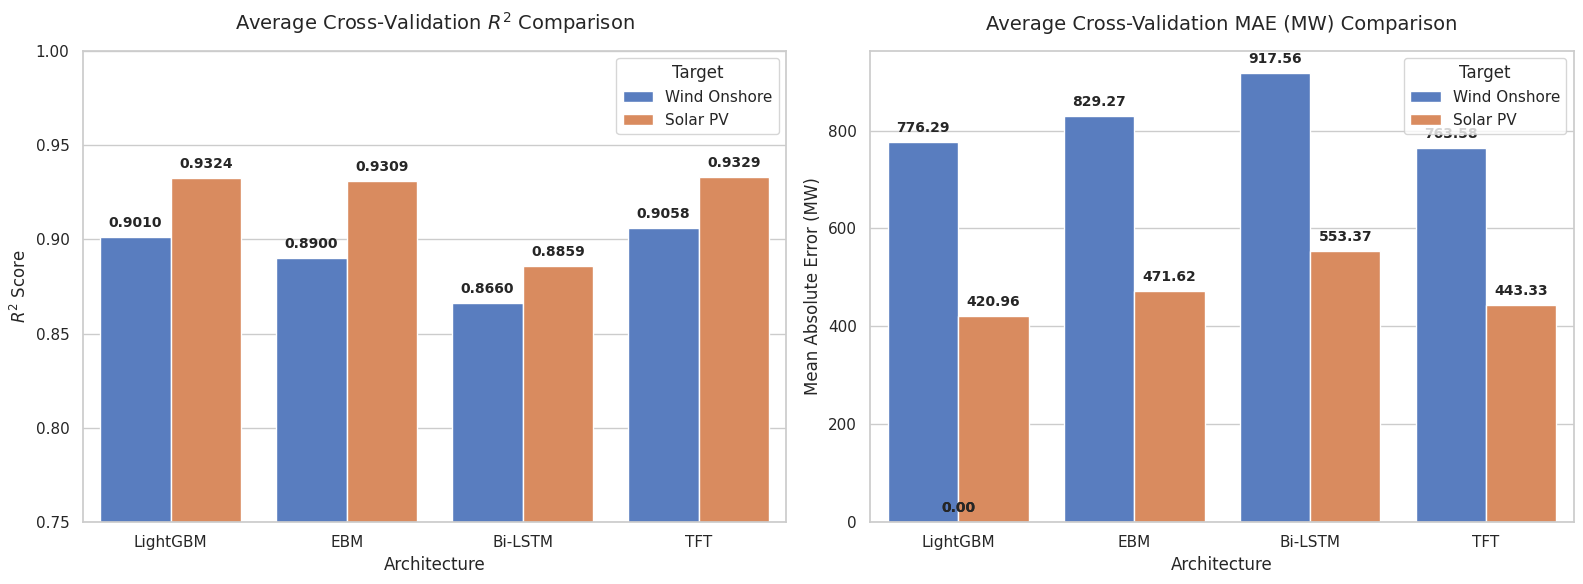

In [3]:
# Hardcoded average cross-validation metrics from training logs
models = ['LightGBM', 'EBM', 'Bi-LSTM', 'TFT']

# R2 scores
r2_wind = [0.9010, 0.8900, 0.8660, 0.9058]
r2_solar = [0.9324, 0.9309, 0.8859, 0.9329]

# MAE scores
mae_wind = [776.29, 829.27, 917.56, 763.58]
mae_solar = [420.96, 471.62, 553.37, 443.33]

# Prepare data for plotting
df_metrics = pd.DataFrame({
    'Model': models * 2,
    'Target': ['Wind Onshore'] * 4 + ['Solar PV'] * 4,
    'R2': r2_wind + r2_solar,
    'MAE': mae_wind + mae_solar
})

# Set style
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Panel: R2 comparison
ax_r2 = sns.barplot(
    data=df_metrics,
    x='Model',
    y='R2',
    hue='Target',
    ax=axes[0],
    palette='muted'
)
axes[0].set_title('Average Cross-Validation $R^2$ Comparison', fontsize=14, pad=15)
axes[0].set_ylabel('$R^2$ Score', fontsize=12)
axes[0].set_xlabel('Architecture', fontsize=12)
axes[0].set_ylim(0.75, 1.0)  # Highlight differences in the high R2 regime

# Add data labels
for p in ax_r2.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax_r2.annotate(
            f'{height:.4f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            xytext=(0, 5), textcoords='offset points',
            fontsize=10, fontweight='semibold'
        )

# Right Panel: MAE comparison
ax_mae = sns.barplot(
    data=df_metrics,
    x='Model',
    y='MAE',
    hue='Target',
    ax=axes[1],
    palette='muted'
)
axes[1].set_title('Average Cross-Validation MAE (MW) Comparison', fontsize=14, pad=15)
axes[1].set_ylabel('Mean Absolute Error (MW)', fontsize=12)
axes[1].set_xlabel('Architecture', fontsize=12)

# Add data labels
for p in ax_mae.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax_mae.annotate(
            f'{height:.2f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            xytext=(0, 5), textcoords='offset points',
            fontsize=10, fontweight='semibold'
        )

plt.tight_layout()
plt.show()

## Out-of-Sample Regression Metrics (MW scale)

Every trainer (`train_lightgbm.py`, `train_ebm.py`, `train_bilstm.py`, `train_tft.py`) already
writes its purged-CV fold metrics to `results/macro_cv_metrics.csv` via the shared
`src/evaluation/metrics.cv_rows`/`append_cv_metrics`. We just read that file here — no retraining.

- **RMSE**: Captures larger errors heavily (important for grid stability).
- **Mean Bias Error (MBE)**: Checks whether models systematically over- or under-forecast.

In [4]:
# Read the already-persisted CV metrics instead of retraining models here.
import sys

project_root = Path(os.getcwd())
if project_root.name == 'notebooks':
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

df_cv = pd.read_csv(project_root / 'results/macro_cv_metrics.csv')

model_display = {'lightgbm': 'LightGBM', 'ebm': 'EBM', 'bilstm': 'Bi-LSTM', 'tft': 'TFT'}
target_display = {'wind': 'Wind Onshore', 'solar': 'Solar PV'}

# scale='cf' is used (not 'mw') because train_tft.py's cv_rows call doesn't pass
# cap/y_mw, so TFT only has capacity-factor-scale rows in the CSV; cf is the
# only scale all four trainers persist.
df_cv = df_cv[(df_cv['model'].isin(model_display)) & (df_cv['scale'] == 'cf')].copy()
df_cv['Model'] = df_cv['model'].map(model_display)
df_cv['Target'] = df_cv['technology'].map(target_display)

df_summary = df_cv.groupby(['Model', 'Target'])[['rmse', 'mbe']].mean().reset_index()
df_summary = df_summary.rename(columns={'rmse': 'RMSE', 'mbe': 'MBE'})
df_summary

,Model,Target,RMSE,MBE
0,Bi-LSTM,Solar PV,0.072156,-0.004643
1,Bi-LSTM,Wind Onshore,0.082907,-0.012955
2,EBM,Solar PV,0.052298,0.000213
3,EBM,Wind Onshore,0.072140,-0.004117
4,LightGBM,Solar PV,0.050803,-0.001111
5,LightGBM,Wind Onshore,0.067996,-0.003876
6,TFT,Solar PV,0.052448,-0.001054
7,TFT,Wind Onshore,0.068970,-0.004808


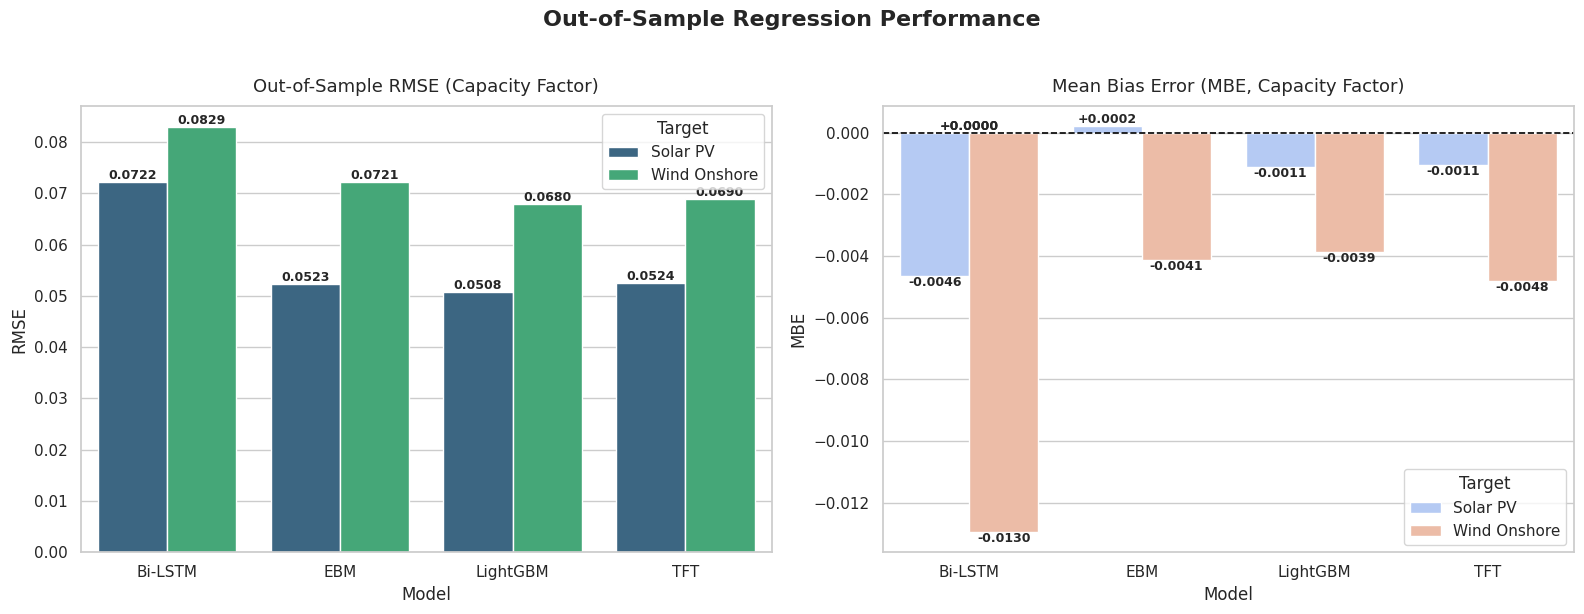

In [5]:
# Visualize the persisted Regression Metrics (RMSE, MBE)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Root Mean Squared Error (RMSE)
ax0 = sns.barplot(data=df_summary, x='Model', y='RMSE', hue='Target', ax=axes[0], palette='viridis')
axes[0].set_title('Out-of-Sample RMSE (Capacity Factor)', fontsize=13, pad=10)
for p in ax0.patches:
    h = p.get_height()
    if h > 0: ax0.annotate(f'{h:.4f}', (p.get_x() + p.get_width()/2., h), ha='center', va='bottom', fontsize=9, fontweight='semibold')

# 2. Mean Bias Error (MBE / Systematic Deviation)
ax1 = sns.barplot(data=df_summary, x='Model', y='MBE', hue='Target', ax=axes[1], palette='coolwarm')
axes[1].set_title('Mean Bias Error (MBE, Capacity Factor)', fontsize=13, pad=10)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
for p in ax1.patches:
    h = p.get_height()
    ax1.annotate(f'{h:+.4f}', (p.get_x() + p.get_width()/2., h), ha='center', va='bottom' if h >= 0 else 'top', fontsize=9, fontweight='semibold')

plt.suptitle('Out-of-Sample Regression Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Global Feature Importance Comparison: Glass-Box EBM vs. LightGBM SHAP

We compare the normalized feature importances of the Explainable Boosting Machine (EBM) and the mean absolute SHAP values from LightGBM. Both models are trained on the wind onshore targets to examine how each method values physical capacity priors versus meteorological inputs.

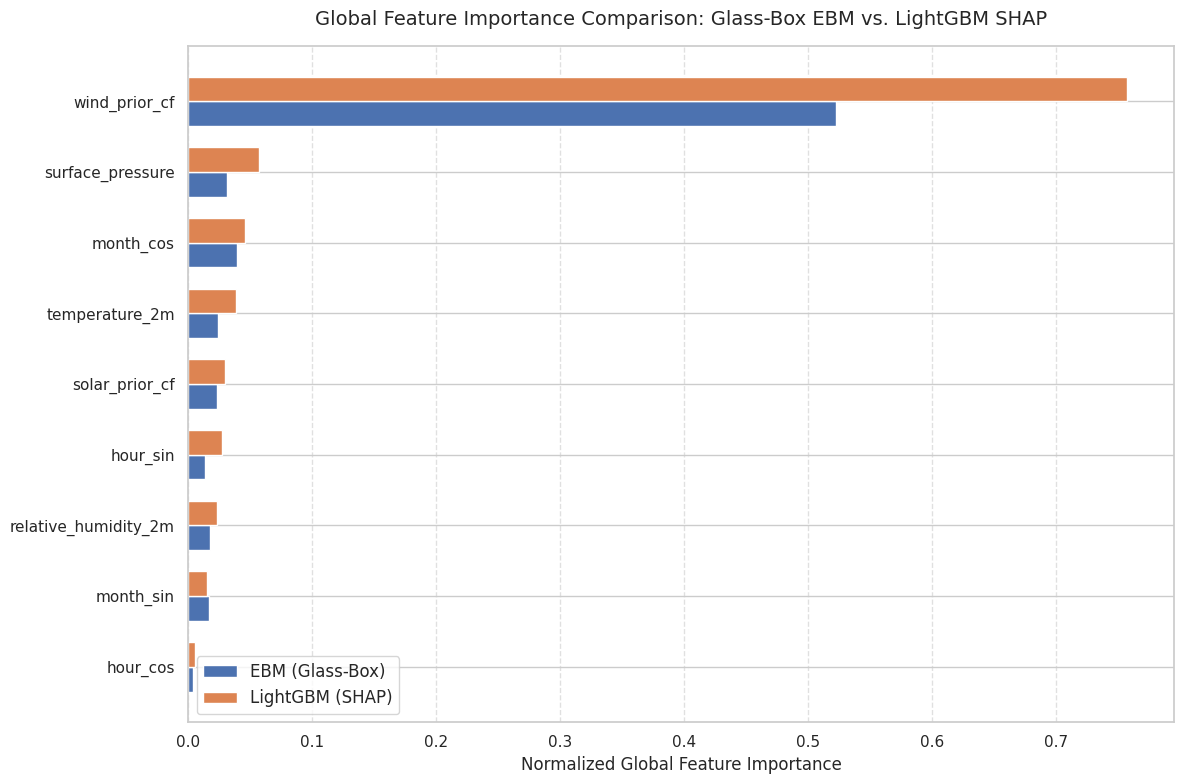

In [6]:
# Resolve paths dynamically to support both notebook directory and project root execution
project_root = Path(os.getcwd())
if project_root.name == 'notebooks':
    project_root = project_root.parent

# 1. Load EBM wind feature importance
ebm_imp_path = project_root / 'results/ebm_wind_importance.csv'
ebm_imp = pd.read_csv(ebm_imp_path)

# Normalize EBM importances so they sum to 1
ebm_imp['NormalizedImportance_EBM'] = ebm_imp['ImportanceScore'] / ebm_imp['ImportanceScore'].sum()
ebm_imp = ebm_imp[['Feature', 'NormalizedImportance_EBM']]

# 2. Compute LightGBM SHAP values
# Load the trained LightGBM model
lgb_model = joblib.load(project_root / 'models/lightgbm_wind.pkl')

# Load the feature dataset. The model was trained on exactly FEATURE_COLS (the
# scale-free CF-prior + weather + cyclical-time contract in src/features/schema.py) —
# SHAP needs the identical column set or TreeExplainer errors on a feature-count mismatch.
from src.features.schema import FEATURE_COLS
matrix_path = project_root / 'data/processed/ml_training_matrix.parquet'
df = pd.read_parquet(matrix_path)
if 'timestamp_utc' in df.columns:
    df = df.set_index(pd.to_datetime(df['timestamp_utc'], utc=True))
else:
    df.index = pd.to_datetime(df.index, utc=True)

X = df[FEATURE_COLS]

# Sample uniform/random rows for TreeExplainer
X_sample = X.sample(n=min(2000, len(X)), random_state=42)

# Run SHAP explainer
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

mean_abs_shap = np.abs(shap_values).mean(axis=0)

lgb_imp = pd.DataFrame({
    'Feature': X.columns,
    'NormalizedImportance_LGB': mean_abs_shap / mean_abs_shap.sum()
})

# 3. Merge and Sort
merged = pd.merge(ebm_imp, lgb_imp, on='Feature')
# Sort features in descending order of LightGBM importance for plotting
merged = merged.sort_values(by='NormalizedImportance_LGB', ascending=True)

# 4. Side-by-side horizontal bar plot
fig, ax = plt.subplots(figsize=(12, 8))
y = np.arange(len(merged))
width = 0.35

ax.barh(y - width/2, merged['NormalizedImportance_EBM'], width, label='EBM (Glass-Box)', color='#4c72b0')
ax.barh(y + width/2, merged['NormalizedImportance_LGB'], width, label='LightGBM (SHAP)', color='#dd8452')

ax.set_yticks(y)
ax.set_yticklabels(merged['Feature'], fontsize=11)
ax.set_xlabel('Normalized Global Feature Importance', fontsize=12)
ax.set_title('Global Feature Importance Comparison: Glass-Box EBM vs. LightGBM SHAP', fontsize=14, pad=15)
ax.legend(fontsize=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()